# Lab 2: RRT Implementation and Hardware Deployment

In this lab, you will first implement the Rapidly-Exploring Random Tree (RRT) algorithm discussed in class, then work in a team to deploy it on real hardware. This is also the first lab where you'll fly the physical Crazyflie, so **Part I** walks you through connecting to your drone.

We have set up obstacles in the drone cage (note that the obstacles are in different positions for each netted area). You will measure the positions of the obstacles, field, and starting/end locations, and use your RRT implementation to find a trajectory through the space. There are measuring tapes in the lab that you can use to make the measurements. We provide the code to run the drone through a sequence of (x, y) setpoints. You will be graded on your ability to autonomously navigate the drone from the starting position to the end goal location -- make sure your submitted video includes the drone landing within the end position. The starting position is marked with an 'X' inside a square, and the end position is marked with just a square. 

You will work as a team. **Only one** team member should submit your team's video to Gradescope.

## Part I: Testing out the Crazyflie 

Assembled drones are provided in the lab spaces. 

Please **carefully read the instructions** for building the drone [here](https://www.bitcraze.io/documentation/tutorials/getting-started-with-crazyflie-2-x/). Even though you have a pre-built drone, the instructions contain a lot of useful information about working with the drone (e.g., the correct configuration of propellers, how to attach the battery, how to switch the drone on/off, the meaning of different LED patterns, etc.).

Ensure that you have activated the mae345 conda environment. Then, follow the instructions for your operating system below. Note: Using a Mac (without the M-Series chips) is probably the easiest option of the options. For this lab, prioritize setting up at least one person in your team with the software for running the Crazyflie. If you are able to get multiple laptops setup, that's great (but not critical at this stage in the course!).

### Linux

`pip install cflib libusb cfclient`

Linux only: Update the UDEV rules to recognize the Crazyflie Radio by following the instructions at the end of this [page](https://github.com/bitcraze/crazyflie-lib-python/blob/master/docs/installation/install.md). After completing them, you may need to reboot your computer.

### Windows

Follow all installation instructions [here](https://github.com/bitcraze/crazyradio-firmware/blob/master/docs/building/usbwindows.md). You should repeat the driver installation twice: first with the Crazyflie connected by USB, then again with the radio receiver connected.

`pip install cflib libusb cfclient`

### Mac (without the Apple M-Series chip)

These instructions are for Macs with Intel chips (i.e., before Apple moved to the M-Series chip). See below for instructions for newer Macs with the M-Series chip. If you are unsure what kind of chip your Mac has, click on the Apple logo on the top left of your desktop, click on "About this Mac" and see what kind of chip is listed (Intel or M1).

Now, make sure you have the `brew` package manager installed. You can check if it is already installed by running `brew help` in your terminal. If you see some output, then continue to the next step. If brew is not installed, install it using the terminal command [here](https://brew.sh/).

Next, in your terminal, run:

`brew install libusb`

Then, run the following (make sure that you are running this from the mae345 conda environment):

`pip install cflib libusb cfclient`


### Mac (with the Apple M-Series chip)

These instructions are for newer Macs that use the Apple M-Series chip. Run the following instructions using conda:

Activate mae345 environment

`conda activate mae345`

Install crazyflie packages in conda environment

`pip install cfclient libusb cflib`

Deactivate out of conda environment

`conda deactivate`

`conda config --set auto_activate_base false`

Conda has trouble accessing the necessary software to get cfclient up and running. To get cfclient working, run the following commands in a terminal (not conda):

Navigate to wherever you want the virtual environment to be created (the given path is just an example):

`cd ../Users/YOURNAME/Desktop/F2026`

Create a virtual environment (not conda). If you do not have python installed, try `python3` instead.

`python -m venv drone`

Activate the virtual environment

`source bin/activate`

Install cfclient

`pip install cfclient`


### After installing these packages:
Run `cfclient` in terminal (Mac) or Anaconda Prompt (Windows). Remember to activate the necessary virtual environment in terminal (Mac) or Anaconda Prompt (Windows). For Linux, run the command `python -m cfclient.gui` in terminal and make sure your drone is on. If you receive an error regarding `pysdl2`, install the required packages as described [here](https://github.com/bitcraze/crazyflie-clients-python/issues/592) based on your operating system (`pip install pysdl2 pysdl2-dll`).

The `cfclient` software is a GUI for interacting with the Crazyflie. Connect the Crazyflie to your computer by USB and turn it on. Then, hit `Scan` in the upper left of the window and from the drop down menu pick `usb://0` and hit `Connect`. This uses the USB interface to connect to the drone. In the console tab (hit `View -> Tabs -> Console` if it isn't present), you should see `Crazyflie 2.1 is up and running!` followed by other information.

The last thing we have to do is set the radio channel the Crazyflie will operate on -- this prevents other teams from sending commands to your drone (or your commands to theirs). Hit `Connect -> Configure 2.X`. Set the radio channel option in the dialog box that appears to **Ch.\<your drone's number\>** (this is the number assigned to the specific drone you're using -- the number is marked on the drone with a label). Also make sure that the radio bandwith is 2 MBit/s (if it's set to something else, change it to 2 MBit/s). Hit `Write` (if you don't, this won't be saved). Now, change the value of the variable in the cell below to your drone's number.

In [44]:
drone_number = 2  # TODO: set this to your drone's radio channel number. It should match the number on your drone

Next, disconnect the Crazyflie from the USB and plug in the CrazyRadio (provided to you in your drone's box), hit the `Disconnect` button and `Scan` again. You should see an address that looks something like `radio://0/<drone_number>/2M`. You don't need to connect to it again, and, in fact, **you can't command the drone via Python while it's connected to the GUI**. However, you should confirm the address exists.

To check that everything is working properly, run the following cell. It will print a bunch of logging information (specifically the roll, pitch, and yaw of the drone).

### Important tips for working with the Crazyflie

- The connection with the drone is not always the most stable. Sometimes, a glitch occurs and you may need to restart the drone and / or Jupyter. To restart Jupyter, open the terminal where you ran `jupyter notebook` and hit `Ctrl + C` followed by `y` and `ENTER`.
- Sometimes the drone gets a poor initialization before flying. If it crashes before stabilizing at the hover point, it is unlikely your code is wrong. You may need to just run it again. **It helps to plug in the battery/powering the drone on when it is flat on a surface; the drone calibrates its sensors when you switch it on.**
- **Turn the drone on when it is plugged in to charge it!** It will not charge when it is powered off so that the onboard processor can monitor the battery and prevent it from overcharging.
- We have provided battery chargers in the labs. Don't wait until your current battery is discharged before charging other ones. **Disconnect all batteries before leaving the lab. We do not want to cause a fire!** 
- See [this page](https://github.com/Princeton-Introduction-to-Robotics/F2022/blob/main/crazyflie-tips.md) for a compilation of useful tips. 

In [45]:
# This is an example from the Crazyflie Python API.
# See https://github.com/bitcraze/crazyflie-lib-python/blob/master/examples/basiclogSync.py

import logging
import time

import cflib.crtp
from cflib.crazyflie import Crazyflie
from cflib.crazyflie.log import LogConfig
from cflib.crazyflie.syncCrazyflie import SyncCrazyflie
from cflib.crazyflie.syncLogger import SyncLogger

# Only output errors from the logging framework
logging.basicConfig(level=logging.ERROR)


# Initialize the low-level drivers (don't list the debug drivers)
cflib.crtp.init_drivers(enable_debug_driver=False)
# Scan for Crazyflies and use the first one found
print('Scanning interfaces for Crazyflies...')
available = cflib.crtp.scan_interfaces()
print('Crazyflies found:')
for i in available:
    print(i[0])

if len(available) == 0:
    print('No Crazyflies found, cannot run example')
else:
    lg_stab = LogConfig(name='Stabilizer', period_in_ms=10)
    lg_stab.add_variable('stabilizer.roll', 'float')
    lg_stab.add_variable('stabilizer.pitch', 'float')
    lg_stab.add_variable('stabilizer.yaw', 'float')

    cf = Crazyflie(rw_cache='./cache')
    with SyncCrazyflie(available[0][0], cf=cf) as scf:
        with SyncLogger(scf, lg_stab) as logger:
            endTime = time.time() + 10

            for log_entry in logger:
                timestamp = log_entry[0]
                data = log_entry[1]
                logconf_name = log_entry[2]

                print('[%d][%s]: %s' % (timestamp, logconf_name, data))

                if time.time() > endTime:
                    break

Scanning interfaces for Crazyflies...
Crazyflies found:
radio://0/1/2M
radio://0/2/2M
radio://0/1/2M
radio://0/2/2M
radio://0/1/2M
radio://0/2/2M
radio://0/1/2M
radio://0/2/2M
radio://0/1/2M
radio://0/2/2M
radio://0/1/2M
radio://0/2/2M
radio://0/1/2M
radio://0/2/2M
[42881][<cflib.crazyflie.log.LogConfig object at 0x11e3d8f70>]: {'stabilizer.roll': 0.0, 'stabilizer.pitch': 0.0, 'stabilizer.yaw': 0.0}
[42891][<cflib.crazyflie.log.LogConfig object at 0x11e3d8f70>]: {'stabilizer.roll': 0.0, 'stabilizer.pitch': 0.0, 'stabilizer.yaw': 0.0}
[42901][<cflib.crazyflie.log.LogConfig object at 0x11e3d8f70>]: {'stabilizer.roll': 0.0, 'stabilizer.pitch': 0.0, 'stabilizer.yaw': 0.0}
[42911][<cflib.crazyflie.log.LogConfig object at 0x11e3d8f70>]: {'stabilizer.roll': 0.0, 'stabilizer.pitch': 0.0, 'stabilizer.yaw': 0.0}
[42921][<cflib.crazyflie.log.LogConfig object at 0x11e3d8f70>]: {'stabilizer.roll': 0.0, 'stabilizer.pitch': 0.0, 'stabilizer.yaw': 0.0}
[42931][<cflib.crazyflie.log.LogConfig object at 

KeyboardInterrupt: 



## Part II: Rapidly-Exploring Random Trees (60 Pts)

Now that your drone is set up, we'll implement the Rapidly-Exploring Random Tree algorithm discussed in class. If you need a reference outside of the class notes, you can consult [Lavalle's textbook](http://planning.cs.uiuc.edu), or [his 1998 paper on the topic](http://msl.cs.illinois.edu/~lavalle/papers/Lav98c.pdf) --- both of which are very accessible. You will reuse the functions you write here later in Part IV to fly the drone through the obstacle course, so keep the implementation general. First, let's begin with some imports:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple

%matplotlib inline

### A Note on Terminology

The literature on motion planning sometimes means different things by the terms "configuration space" and "free space". In this assignment, we define the _configuration space_ to be the set of robot configurations the robot can be placed in when we ignore obstacles. This is the definition we used in class. In addition, we define the _free space_ to bet the set of configurations that do not place the robot in intersection with one or more obstacles.

To keep things simple, we will assume that the robot is a point that can move in the plane. The configuration space is thus (a subset of) $\mathbb{R}^2$. 

### Problem 1: Checking for Free Configurations (10 Pts)

In this part, we will write functions for checking if configurations and lines between configurations are in the free space.

Configurations are represented as `np.ndarray` types with dimension `(2,)`. That is, they are a vector where the first entry is the $x$ coordinate and the second entry is the $y$ coordinate. Edges of the graph, which in this assignment are straight line segments, are represented as a tuple containing the two endpoints of the line segment.

All the obstacles that we work with are circles. These are represented in our code as a tuple, where the first entry is an `np.ndarray` containing the center of the circle and the second entry is the radius of the circle.

Fill out the following two functions in adherence to the behavior specified in their docstrings. Note that there are multiple ways to test if a line intersects a circle. You are free to use any method that you wish. These Wikipedia articles may be useful:
- [Distance from a Point to a Line](https://en.wikipedia.org/wiki/Distance_from_a_point_to_a_line)
- [Line-Sphere Intersection](https://en.wikipedia.org/wiki/Line–sphere_intersection)

Throughout this assignment, you are free to use any of the functions in NumPy (especially its `linalg` module) to fill out the code.

In [2]:
def conf_free(q: np.ndarray, obstacles: List[Tuple[np.ndarray, float]]) -> bool:
    """
    Check if a configuration is in the free space.

    This function checks if the configuration q lies outside of all the obstacles in the connfiguration space.

    @param q: An np.ndarray of shape (2,) representing a robot configuration.
    @param obstacles: A list of obstacles. Each obstacle is a tuple of the form (center, radius) representing a circle.
    @return: True if the configuration is in the free space, i.e. it lies outside of all the circles in `obstacles`.
             Otherwise return False.
    """

    for ob in obstacles:
        ob_center = ob[0]
        ob_radius = ob[1]
        if np.linalg.norm(q - ob_center) <= ob_radius:
            return False

    return True
    

def edge_free(edge: Tuple[np.ndarray, np.ndarray], obstacles: List[Tuple[np.ndarray, float]]) -> bool:
    """
    Check if a graph edge is in the free space.

    This function checks if a graph edge, i.e. a line segment specified as two end points, lies entirely outside of
    every obstacle in the configuration space.

    @param edge: A tuple containing the two segment endpoints.
    @param obstacles: A list of obstacles as described in `config_free`.
    @return: True if the edge is in the free space, i.e. it lies entirely outside of all the circles in `obstacles`.
             Otherwise return False.
    """
    pointA = edge[0]
    pointB = edge[1]

    for obs in obstacles:
        obs_center = obs[0]
        obs_rad = obs[1]

        num = np.abs((pointB[1]-pointA[1])*obs_center[0]
                        - (pointB[0]-pointA[0])*obs_center[1]
                        + pointB[0]*pointA[1]
                        - pointB[1]*pointA[0])

        denom = np.sqrt((pointB[1] - pointA[1])**2 + (pointB[0] - pointA[0])**2)

        # Distance of obs center to edge line segment
        distance = num / denom

        # Compare distance to obstacle radii
        if distance <= obs_rad:
            return False

    return True


In [3]:
q = np.array([10, 2])
obs_center = np.array([0,0])
obs_radius = 1
obstacles = [(obs_center, obs_radius)]
conf_free(q, obstacles)

True

In [4]:
edge = np.array([[-14, 11], [10,0]])
obs_center = np.array([0,0])
obs_radius = 1
obstacles = [(obs_center, obs_radius)]
edge_free(edge, obstacles)

True

### Problem 2: Sampling the Configuration Space (10 Pts)

The next function we need is one to randomly sample the configuration space. Our configuration space is assumed to be a rectangle with a specified height and width. You should use [np.random.rand](https://docs.scipy.org/doc/numpy-1.14.0/reference/generated/numpy.random.rand.html) to sample random numbers.

In [5]:
def random_conf(width: float, height: float) -> np.ndarray:
    """
    Sample a random configuration from the configuration space.

    This function draws a uniformly random configuration from the configuration space rectangle. The configuration
    does not necessarily have to reside in the free space.

    @param width: The configuration space width.
    @param height: The configuration space height.
    @return: A random configuration uniformily distributed across the configuration space.
    """
    arr = np.random.rand(2,)
    arr[0] *= width
    arr[1] *= height
    return arr

In [6]:
random_conf(100,5)

array([29.47847929,  2.86121541])

### Problem 3: The `Extend` Function (10 Pts)

We're almost ready to write our RRT function. The last thing we need are functions that find the nearest vertex to our sampled vertex and the function that creates the new extension vertex in the direction of the sampled one.

We represent all the vertices in the graph as an `np.ndarray` with shape `(n, 2)` where `n` is the number of vertices. In this array, each row represents a vertex. This representation is very convient for how NumPy functions work with their arguments. Fill out the two following functions.

In [7]:
def nearest_vertex(conf: np.ndarray, vertices: np.ndarray) -> int:
    """
    Finds the nearest vertex to conf in the set of vertices.

    This function searches through the set of vertices and finds the one that is closest to
    conf using the L2 norm (Euclidean distance).

    @param conf: The configuration we are trying to find the closest vertex to.
    @param vertices: The set of vertices represented as an np.array with shape (n, 2). Each row represents
                     a vertex.
    @return: The index (i.e. row of `vertices`) of the vertex that is closest to `conf`.
    """

    best_distance = np.inf
    best_index = 0

    for i in range(len(vertices)):
        d = np.linalg.norm(conf - vertices[i])
        if d < best_distance: 
            best_distance = d
            best_index = i 

    return best_index
    

def extend(origin: np.ndarray, target: np.ndarray, step_size: float=0.2) -> np.ndarray:
    """
    Extends the RRT at most a fixed distance toward the target configuration.

    Given a configuration in the RRT graph `origin`, this function returns a new configuration that takes a
    step of at most `step_size` towards the `target` configuration. That is, if the L2 distance between `origin`
    and `target` is less than `step_size`, return `target`. Otherwise, return the configuration on the line
    segment between `origin` and `target` that is `step_size` distance away from `origin`.

    @param origin: A vertex in the RRT graph to be extended.
    @param target: The vertex that is being extended towards.
    @param step_size: The maximum allowed distance the returned vertex can be from `origin`.

    @return: A new configuration that is as close to `target` as possible without being more than
            `step_size` away from `origin`.
    """

    # Compute euclidean distance between origin and target
    distance = np.linalg.norm(origin - target)

    # if distance <= step_size, simply append point
    if distance <= step_size:
        return target

    # otherwise compute new point step distance away from origin by step_size
    step = (target - origin) * step_size
    
    return origin + step

In [8]:
origin = np.array([1,1])
target = np.array([3,2])
extend(origin, target)

array([1.4, 1.2])

### Problem 4: Putting It All Together (30 Pts)

Finally, you have all the components you need to implement the RRT algorithm. The last thing that needs to be discussed is how to represent the graph that the RRT produces. Since this graph is a _tree_, a simple way is to represent the set of vertices as an `np.ndarray` of shape `(n, 2)` as discussed in the previous problem and then to maintain a list that specifies the parent vertex of each vertex. That is, to keep an `np.array` named `parents` such that if the parent of vertex `i` is `j`, then `parents[i] == j` is `True`.

After we construct the graph then, we can just select any vertex in the goal region and backtrack through this array to the start configuration to find a feasible trajectory. We will assign the parent of the starting configuration to be `-1`.

Fill out the main loop of the RRT algorithm and the backtracking function below.

In [9]:
def rrt(origin: np.ndarray, width: float, height: float, obstacles: List[Tuple[np.ndarray, float]],
        trials: int=1500, step_size: float=0.2) -> (np.ndarray, np.ndarray):
    """
    Explore a workspace using the RRT algorithm.

    This function builds an RRT using `trials` samples from the free space.

    @param origin: The starting configuration of the robot.
    @param width: The width of the configuration space.
    @param height: The height of the configuration space.
    @param obstacles: A list of circular obstacles.
    @param trials: The number of configurations to sample from the free space.
    @param step_size: The step_size to pass to `extend`.

    @return: A tuple (`vertices`, `parents`), where `vertices` is an (n, 2) `np.ndarray` where each row is a configuration vertex
             and `parents` is an array identifying the parent, i.e. `parents[i]` is the parent of the vertex in
             the `i`th row of `vertices.
    """
    num_verts = 1

    vertices = np.zeros((trials + 1, len(origin)))
    vertices[0, :] = origin

    parents = np.zeros(trials + 1, dtype=int)
    parents[0] = -1

    # rrt algorithm as shown in lecture 3, with parents array
    for _ in range(trials):
        x_rand = random_conf(width, height)

        x_near_index = nearest_vertex(x_rand, vertices[:num_verts])

        q_s = extend(vertices[x_near_index], x_rand, step_size)

        if  conf_free(q_s, obstacles) and edge_free((vertices[x_near_index], q_s), obstacles):
            vertices[num_verts] = q_s
            parents[num_verts] = x_near_index
            num_verts += 1

    return vertices[:num_verts, :], parents[:num_verts]

def backtrack(index: int, parents: np.ndarray) -> List[int]:
    """
    Find the sequence of nodes from the origin of the graph to an index.

    This function returns a List of vertex indices going from the origin vertex to the vertex `index`.

    @param index: The vertex to find the path through the tree to.
    @param parents: The array of vertex parents as specified in the `rrt` function.

    @return: The list of vertex indicies such that specifies a path through the graph to `index`.
    """

    i = index
    res = []
    while i != -1:
        res.insert(0, i)
        i = parents[i]

    return res

The next two cells run the RRT and plot the result on a synthetic example (not the real drone cage) so you can test your implementation on your laptop first. Feel free to adjust the `trials` and `step_size` parameters. You shouldn't modify the other code in these cells, and you should submit your notebook with a successful trajectory displayed. The goal region is shown as a circle with a green outline and center point on the plot. Obstacles are in blue.

You'll reuse `rrt` and `backtrack` as-is in Part IV below, this time with a configuration space you measure from the real drone cage.

In [10]:
width = 3
height = 4

obstacles = [(np.array([1, 1]), 0.25), (np.array([2, 2]), 0.25), (np.array([1, 3]), 0.3)]
goal = (np.array([2.5, 3.5]), 0.25)

origin = (0.1, 0.1)

vertices, parents = rrt(origin, width, height, obstacles)

index = nearest_vertex(goal[0], vertices)

if np.linalg.norm(vertices[index, :] - goal[0]) < 0.25:
    print('Path found!')
    path_verts = backtrack(index, parents)
else:
    print('No path found!')
    path_verts = []

Path found!


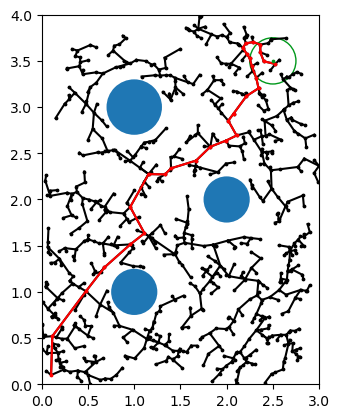

In [11]:
fig, ax = plt.subplots()

ax.set_xlim([0, width])
ax.set_ylim([0, height])
ax.set_aspect('equal')

for i in range(len(parents)):
    if parents[i] < 0:
        continue
    plt.plot([vertices[i, 0], vertices[parents[i], 0]],
             [vertices[i, 1], vertices[parents[i], 1]], c='k')

for i in path_verts:
    if parents[i] < 0:
        continue
    plt.plot([vertices[i, 0], vertices[parents[i], 0]],
             [vertices[i, 1], vertices[parents[i], 1]], c='r')

for o in obstacles:
    ax.add_artist(plt.Circle(tuple(o[0]), o[1]))

ax.add_artist(plt.Circle(tuple(goal[0]), goal[1], ec=(0.004, 0.596, 0.105), fc=(1, 1, 1)))

plt.scatter([2.5], [3.5], zorder=3, c=np.array([[0.004, 0.596, 0.105]]), s=3)
plt.scatter(vertices[path_verts, 0], vertices[path_verts, 1], c=np.array([[1, 0, 0]]), s=3, zorder=2)
plt.scatter(vertices[1:, 0], vertices[1:, 1], c=np.array([[0, 0, 0]]), s=3)

## Part III: Measure the environment in the lab (10 Pts)

Now that you have your RRT code, you can start setting up the code to navigate the drone through the PVC pipe forest.

The drone cages have been set up with a series of PVC pipe obstacles. Your goal is to start your drone in the starting position, marked with an "X" inside a square on the ground in masking tape. You will be graded on your ability to land the drone within the end goal location, marked with an empty square in masking tape. And, of course, you will need to autonomously navigate from start to end while avoiding the obstacles in the drone's path.

**Now: define your configuration space.** You will need to measure the obstacles and their positions, plus whatever other information about the drone cage you think is necessary (relative positions of start/end locations, the width and height of the field, etc.). For the boundary of the space, please make sure to use the rectangular region marked by the orange tape; your drone should not leave this rectangular region as it goes from start to end. Once these measurements are collected, you will simulate your trajectory through the cage below using the same `rrt`/`backtrack` functions you wrote in Part II. Think: How will you handle absolute positions vs. relative positions to the starting location?

**It's also important to remember that for the Crazyflie, the positive X direction is forward (where the nub is) and the positive Y direction is to the left when you stand behind the drone**.

There is one additional caveat: **Remember to "inflate" your obstacles**, so that there is a buffer zone around each one. In practice, this will be necessary to help give the drone adequate space from each PVC pipe. We leave it up to you to assess how much to inflate the obstacles.

Once you have taken these measurements, fill out the code below:

In [ ]:
## Sample code to define the space/obstacles and run the RRT:

## TODO: Take measurements of THIS SEMESTER'S arena and edit this block of code correspondingly.
## The arena/obstacle layout is not fixed across semesters -- re-measure it each time.

# If you measure in feet, convert to meters here -- send_position_setpoint() and the
# onboard estimator are SI-only (meters), there is no unit setting. fixed: inches to feet to meters
INCHES_TO_METERS = 0.0254

# Width and height of the rectangular domain:
# index 0 = forward travel (drone +x), index 1 = lateral / side-to-side (drone +y) --
# this MUST match send_position_setpoint(x_forward, y_left, ...) in run_sequence below.
width  = 3.556  # total forward travel distance  (80 inches => 6.66667 ft)
height = 2.032  # total width of the cage (side-to-side) (140 inches => 11.6667 ft )
obs_radius = 0.25 


# Obstacles are represented as tuples, where the first element is an np.ndarray containing the center
# and the second element is the radius of the obstacle. For example (np.array([3, 4]) * ft, 5 * ft).
# This variable is a list of such tuples.
obstacles = [ 
            (np.array([32, -20]) * INCHES_TO_METERS , obs_radius),
             (np.array([40, 22]) * INCHES_TO_METERS, obs_radius),
             (np.array([56, 0]) * INCHES_TO_METERS  , obs_radius),
             (np.array([75.5, -25]) * INCHES_TO_METERS , obs_radius),
             (np.array([78, 24.5]) * INCHES_TO_METERS , obs_radius) 
             ]

# The goal is represented in the same way as an obstacle.
goal = (np.array([108,0]), 0.2) 

# The starting position of the robot.
origin = np.array([0, 0])

# Run the RRT to find the trajectory in this space:
vertices, parents = rrt(origin, width, height, obstacles)

# Check if path was found:
index = nearest_vertex(goal[0], vertices)
if np.linalg.norm(vertices[index, :] - goal[0]) < goal[1]:
    print('Path found!')
    path_verts = backtrack(index, parents)
else:
    print('No path found!')
    path_verts = []

Path found!


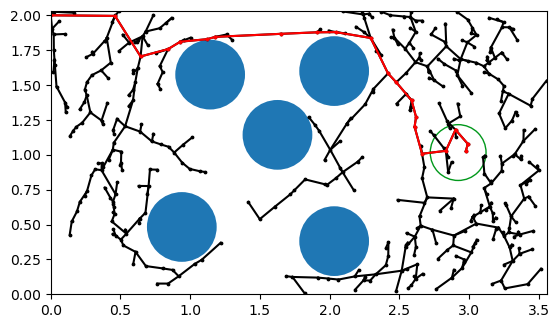

In [38]:
## Sample code to plot the trajectory:

fig, ax = plt.subplots()

ax.set_xlim([0, width])
ax.set_ylim([0, height])
ax.set_aspect('equal')

for i in range(len(parents)):
    if parents[i] < 0:
        continue
    plt.plot([vertices[i, 0], vertices[parents[i], 0]],
             [vertices[i, 1], vertices[parents[i], 1]], c='k')

for i in path_verts:
    if parents[i] < 0:
        continue
    plt.plot([vertices[i, 0], vertices[parents[i], 0]],
             [vertices[i, 1], vertices[parents[i], 1]], c='r')

for o in obstacles:
    ax.add_artist(plt.Circle(tuple(o[0]), o[1]))

ax.add_artist(plt.Circle(tuple(goal[0]), goal[1], ec=(0.004, 0.596, 0.105), fc=(1, 1, 1)))

plt.scatter([2.5], [3.5], zorder=3, c=np.array([[0.004, 0.596, 0.105]]), s=3)
plt.scatter(vertices[path_verts, 0], vertices[path_verts, 1], c=np.array([[1, 0, 0]]), s=3, zorder=2)
plt.scatter(vertices[1:, 0], vertices[1:, 1], c=np.array([[0, 0, 0]]), s=3)

## Part IV: Hardware Implementation (30 Pts)

Now that you have a trajectory, you can begin testing with the drone as a team.

First, define your drone number (as in Part I):

In [19]:
drone_number = 1  # TODO: set this to your drone's radio channel number (same as Part I)

Here, we are providing code which takes your RRT trajectory (assuming the format of the output is consistent with `rrt`/`backtrack` from Part II above) and turns it into a sequence of setpoints which the drone can follow. 

In [20]:
def seg_to_setpoints(start_conf: np.ndarray, end_conf: np.ndarray) -> np.ndarray:
    # This function takes in the RRT trajectory and outputs a sequence of setpoints for the drone to follow.

    dist = np.linalg.norm(start_conf - end_conf)
    num_samples = int(100 * dist)

    return end_conf.reshape((1, 2))

traj = origin.reshape(1, 2)
for i in range(len(path_verts) - 1):
    traj = np.concatenate((traj, seg_to_setpoints(vertices[path_verts[i]], vertices[path_verts[i + 1]])))

Here, we provide the code which actually tells the drone how to follow a sequence of setpoints:

In [21]:
# Code adapted from: https://github.com/bitcraze/crazyflie-lib-python/blob/master/examples/autonomousSequence.py

import time
# CrazyFlie imports:
import cflib.crtp
from cflib.crazyflie import Crazyflie
from cflib.crazyflie.log import LogConfig
from cflib.crazyflie.syncCrazyflie import SyncCrazyflie
from cflib.crazyflie.syncLogger import SyncLogger

## Some helper functions:
## -----------------------------------------------------------------------------------------

# Determine initial position:
def wait_for_position_estimator(scf):
    print('Waiting for estimator to find position...')

    log_config = LogConfig(name='Kalman Variance', period_in_ms=500)
    log_config.add_variable('kalman.varPX', 'float')
    log_config.add_variable('kalman.varPY', 'float')
    log_config.add_variable('kalman.varPZ', 'float')

    var_y_history = [1000] * 10
    var_x_history = [1000] * 10
    var_z_history = [1000] * 10

    threshold = 0.001
    with SyncLogger(scf, log_config) as logger:
        for log_entry in logger:
            data = log_entry[1]

            var_x_history.append(data['kalman.varPX'])
            var_x_history.pop(0)
            var_y_history.append(data['kalman.varPY'])
            var_y_history.pop(0)
            var_z_history.append(data['kalman.varPZ'])
            var_z_history.pop(0)

            min_x = min(var_x_history)
            max_x = max(var_x_history)
            min_y = min(var_y_history)
            max_y = max(var_y_history)
            min_z = min(var_z_history)
            max_z = max(var_z_history)

            print("{} {} {}".
                format(max_x - min_x, max_y - min_y, max_z - min_z))

            if (max_x - min_x) < threshold and (
                    max_y - min_y) < threshold and (
                    max_z - min_z) < threshold:
                break

# Initialize controller:
def set_PID_controller(cf):
    # Set the PID Controller:
    print('Initializing PID Controller')
    cf.param.set_value('stabilizer.controller', '1')
    cf.param.set_value('kalman.resetEstimation', '1')
    time.sleep(0.1)
    cf.param.set_value('kalman.resetEstimation', '0')

    wait_for_position_estimator(cf)
    time.sleep(0.1)
    return

# Ascend and hover:
def ascend_and_hover(cf):
    # Ascend:
    for y in range(20):
        cf.commander.send_hover_setpoint(0, 0, 0, y / 50)
        time.sleep(0.1)
    # Hover at 0.5 meters:
    for _ in range(30):
        cf.commander.send_hover_setpoint(0, 0, 0, 0.5)
        time.sleep(0.1)
    return

# Follow the setpoint sequence trajectory:
def run_sequence(scf, sequence, setpoint_delay):
    cf = scf.cf
    for position in sequence:
        print(f'Setting position {(position[0], (position[1]))}')
        for i in range(setpoint_delay):
            cf.commander.send_position_setpoint(position[0],
                                                (position[1]),
                                                0.5,
                                                0.0)
            time.sleep(0.1)

# Hover, descend, and stop all motion:
def hover_and_descend(cf):
    # Hover at 0.5 meters:
    for _ in range(30):
        cf.commander.send_hover_setpoint(0, 0, 0, 0.5)
        time.sleep(0.1)
    # Descend:
    for y in range(10):
        cf.commander.send_hover_setpoint(0, 0, 0, (10 - y) / 25)
        time.sleep(0.1)
    # Stop all motion:
    for i in range(10):
        cf.commander.send_stop_setpoint()
        time.sleep(0.1)
    return
## -----------------------------------------------------------------------------------------

def run_setpoint_trajectory(drone_number, sequence):
    # This is the main function to enable the drone to follow the trajectory.

    # User inputs:
    #
    # - drone_number: (int) the number corresponding to the drone's radio settings.
    #
    # - sequence: a series of point locations (float) defined as a numpy array, with each row in the following format:
    #     [x(meters), y(meters)]
    #   Note: the input should be given in drone coordinates (where positive x is forward, and positive y is to the left).
    # Example:
    # sequence = [
    #     [[ 0.          0.        ]
    #      [0.18134891  0.08433607]]
    #

    # Outputs:
    # None.

    setpoint_delay = 5 # (int) Time to give the controller to reach next setpoint; in multiples of 0.1 s (bumped from 3 -> 5 to slow the flight down)

    # Set the URI the Crazyflie will connect to
    uri = f'radio://0/{drone_number}/2M'

    # Initialize all the CrazyFlie drivers:
    cflib.crtp.init_drivers(enable_debug_driver=False)

    # Sync to the CrazyFlie:
    with SyncCrazyflie(uri, cf=Crazyflie(rw_cache='./cache')) as scf:
        # Get the Crazyflie class instance:
        cf = scf.cf

        # Initialize and ascend:
        set_PID_controller(cf)

        # >>> KEY DIFFERENCE FOR CRAZYFLIE 2.1 BRUSHLESS <<<
        # Arm the drone. This call is mandatory on the 2.1 Brushless: the motors
        # will not spin without it, and no error is raised if it's skipped --
        # the rest of the sequence just runs against a dead quadrotor. Not
        # needed on the older brushed 2.1. Drone must be flat, still, and
        # props clear when this is sent.
        cf.platform.send_arming_request(True)
        time.sleep(1.0)

        ascend_and_hover(cf)
        # Run the waypoint sequence:
        run_sequence(scf, sequence, setpoint_delay)
        # Descend and stop all motion:
        hover_and_descend(cf)

        # >>> KEY DIFFERENCE FOR CRAZYFLIE 2.1 BRUSHLESS <<<
        # Disarm. Not required (the drone also auto-disarms after
        # send_stop_setpoint), but sent explicitly to match the arming
        # request above and leave the drone in a known-safe state.
        cf.platform.send_arming_request(False)

    print('Done!')
    return

**Putting it all together.**

**The objective: Get from the starting position to the end goal location without collisions.**

Use your RRT trajectory, the code provided to turn the trajectory into a sequence of setpoints, and the code provided to run the sequence of setpoints on the drone.

**Important**: You may need to modify some of your trajectory coordinates in order to get this to work. Think about how you defined your space initially, and then put this in terms of coordinates that the drone can understand. Again, from the perspective of the drone, positive x is **forward**, and positive y is to the **left**. The drone defines its origin at the starting point.


In [22]:
# TODO: Implement any code necessary to convert your setpoint sequence to relative positions for the drone. 

In [27]:
# Run the setpoint sequence on the drone:
run_setpoint_trajectory(drone_number, traj)

Error no LogEntry to handle id=20
Error no LogEntry to handle id=19


Initializing PID Controller
Waiting for estimator to find position...
999.9997240539524 999.9997242866375 999.9997921621107
999.999869285879 999.9998696093971 999.9998032708099
999.999869285879 999.9998696093971 999.9998139491072
999.999869285879 999.9998696093971 999.9998139491072
999.999869285879 999.9998696093971 999.9998139491072
999.9998959020304 999.999895683788 999.9998249960918
999.9998977824725 999.9998977604482 999.9998249960918
999.9998977824725 999.9998977604482 999.9998249960918
999.9998977824725 999.9998977604482 999.9998256883264
0.00017527409363538027 0.00017565375310368836 4.6119806938804686e-05
Setting position (0.0, 1.0)
Setting position (0.23768778744923608, 0.9886882704637161)
Setting position (0.85838791421797, 0.8668040513668744)
Setting position (1.0236331285114428, 0.8749232908642919)
Setting position (1.2550798948599728, 0.842232205497479)
Setting position (1.6776401692092104, 0.9242158219772039)
Setting position (1.9925755135722256, 0.9426956983977282)
Settin

# Submission Instructions

One member from each team should submit this notebook along with a video of a successful flight to the Lab 2 assignment on Gradescope.